
Processing file: 03-17-2026_caliper_calibration_[force_time_x18].csv

STATISTICS FOR EACH TRIAL

Run 1
----------------------------------------
Number of points         = 2206
Mean force               = 0.709937 N
Median force             = -0.170000 N
Standard deviation       = 2.226603 N
Variance                 = 4.957763 N^2
Minimum force            = -1.370000 N
Maximum force            = 13.390000 N
Range                    = 14.760000 N
RMS force                = 2.337044 N
Standard error of mean   = 0.047407 N
Coefficient of variation = 313.634151 %
Noise std                = 2.227108 N
Noise RMS                = 2.226603 N

Run 2
----------------------------------------
Number of points         = 1346
Mean force               = 1.002972 N
Median force             = -0.190000 N
Standard deviation       = 4.612495 N
Variance                 = 21.275110 N^2
Minimum force            = -16.270000 N
Maximum force            = 28.080000 N
Range                    = 44.350000 N
RMS f

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


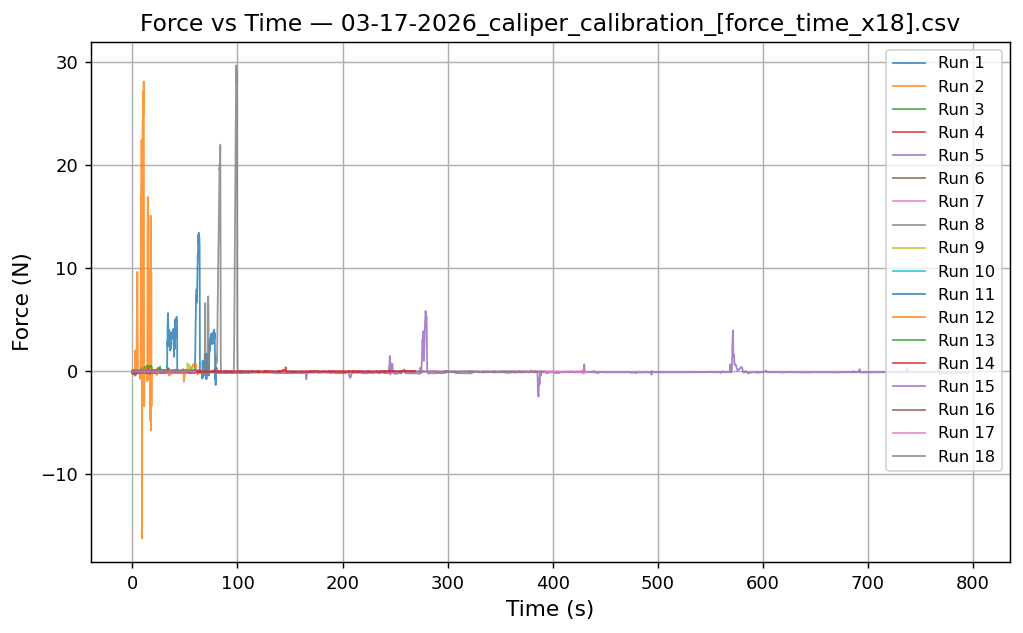

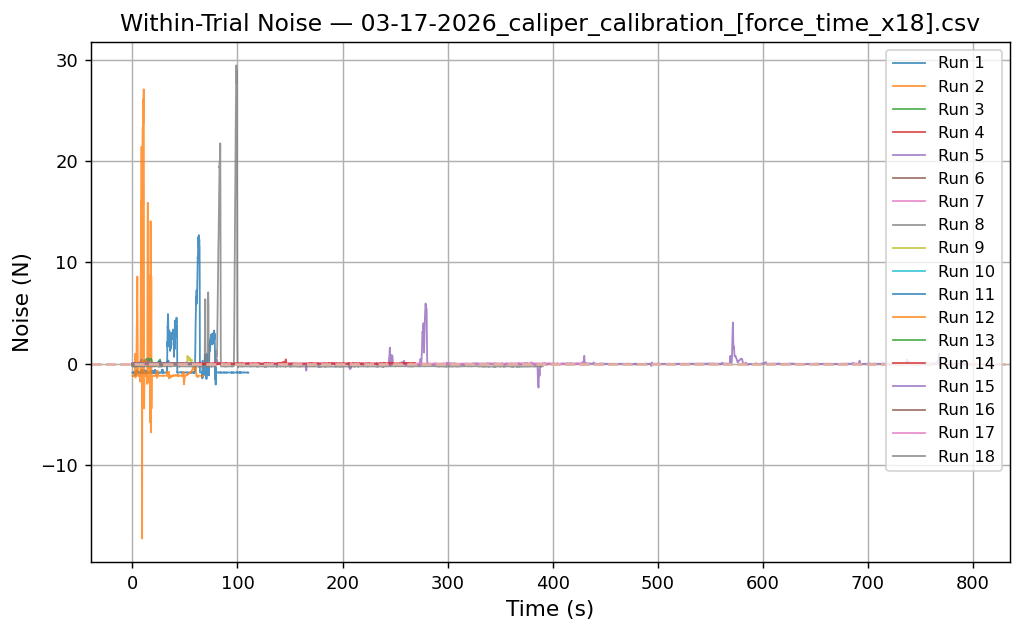

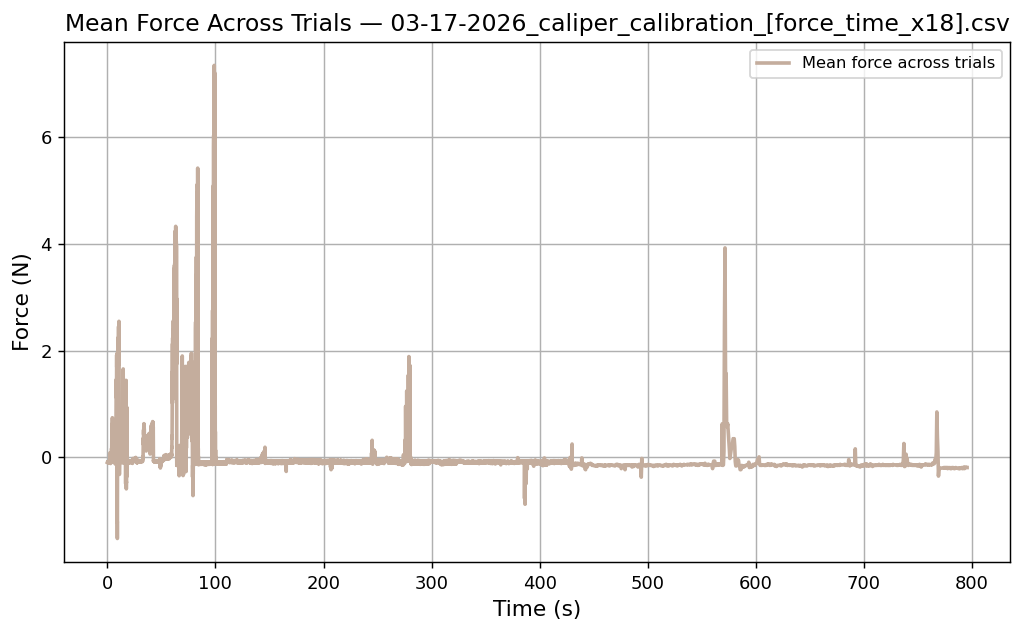

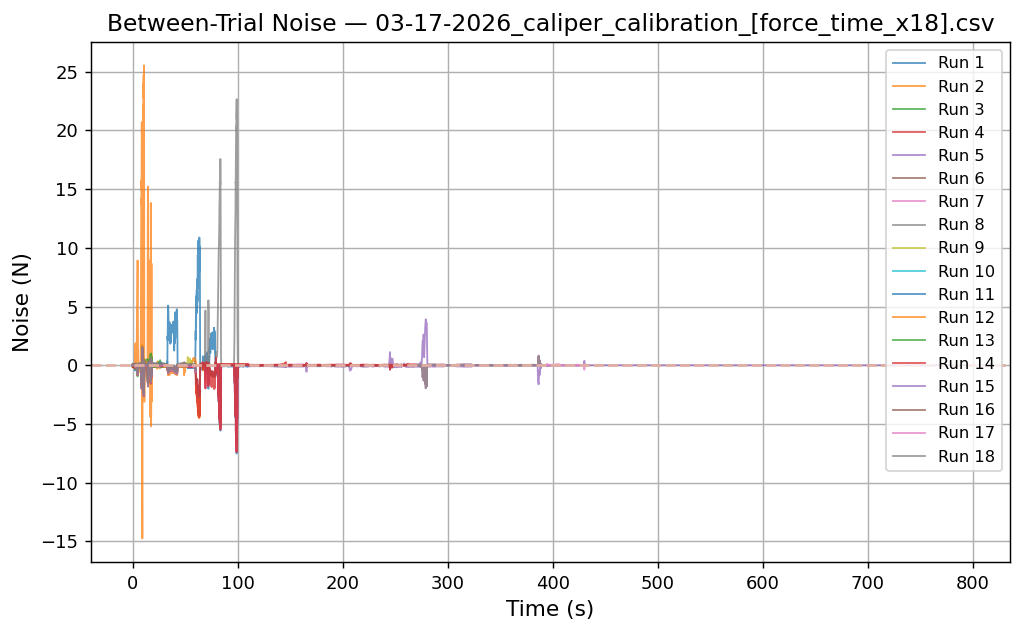

In [ ]:
import glob 
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Preliminary import  (
    file_pattern,
    extract_trials_from_file,
    combine_trials,
    print_trial,
    make_summary_table,
    print_combined_statistics,
    plot_force_for_each_trial,
    plot_noise_for_each_trial,
    plot_mean_force_across_trials,
    plot_between_trial_noise,
)
# ================== Main Program ============
def main():
    csv_files = sorted(glob.glob(file_pattern))

    if not csv_files:
        raise FileNotFoundError(
            f"No matching CSV files found for pattern: {file_pattern}"
        )

    for file_path in csv_files:
        print(f"\nProcessing file: {file_path}")

        # Extract all trials from the file
        trials = extract_trials_from_file(file_path)

        # Combine trials to compare them at the same time values
        combined = combine_trials(trials)

        # Print statistics
        print_trial(trials)

        summary_table = make_summary_table(trials)
        print("\nSummary table:")
        print(summary_table.to_string(index=False))

        print_combined_statistics(combined)

        # Use The filename as the title for plots 
        file_label = file_path.split("/")[-1]

        # Make plots
        plot_force_for_each_trial(trials, file_label)
        plot_noise_for_each_trial(trials, file_label)
        plot_mean_force_across_trials(combined, file_label)
        plot_between_trial_noise(combined, file_label)

    plt.show()

if __name__ == "__main__":
    main()